In [ ]:
!pip install folium
!pip install pandas

In [4]:
# Aperçu général
import pandas as pd

dataframe = pd.read_csv(
    "jeu-de-donnees-liste-des-radars-fixes-en-france-12-2025.csv",
    encoding="latin-1",
    sep=";"
)

print(dataframe.shape)
print(dataframe.dtypes)
dataframe.head()

(3309, 6)
Numéro de radar                str
Type de radar                  str
Date de mise en service        str
VMA                        float64
Latitude                   float64
 Longitude                 float64
dtype: object


,Numéro de radar,Type de radar,Date de mise en service,VMA,Latitude,Longitude
0,12001,ETD,31/10/2011 00:00,70.0,45.36100,4.252600
1,12008,ETD,31/10/2011 00:00,80.0,46.41334,4.436502
2,12014,ETD,21/03/2012 00:00,80.0,46.61972,0.345030
3,12015,ETD,28/03/2012 00:00,80.0,46.61800,0.356000
4,12016,ETD,10/02/2012 00:00,80.0,48.05400,6.587000


In [5]:
# Nettoyage des noms de colonnes
dataframe.columns = dataframe.columns.str.strip()
print(dataframe.columns.tolist())

['Numéro de radar', 'Type de radar', 'Date de mise en service', 'VMA', 'Latitude', 'Longitude']


In [6]:
# Conversion str -> date
dataframe["Date de mise en service"] = pd.to_datetime(
    dataframe["Date de mise en service"], format="%d/%m/%Y %H:%M", errors="coerce"
)

print(dataframe.dtypes)
dataframe.head()

Numéro de radar                       str
Type de radar                         str
Date de mise en service    datetime64[us]
VMA                               float64
Latitude                          float64
Longitude                         float64
dtype: object


,Numéro de radar,Type de radar,Date de mise en service,VMA,Latitude,Longitude
0,12001,ETD,2011-10-31,70.0,45.36100,4.252600
1,12008,ETD,2011-10-31,80.0,46.41334,4.436502
2,12014,ETD,2012-03-21,80.0,46.61972,0.345030
3,12015,ETD,2012-03-28,80.0,46.61800,0.356000
4,12016,ETD,2012-02-10,80.0,48.05400,6.587000


In [7]:
# Vérifications pour voir si il y a des doublons
print("Doublons complets :", dataframe.duplicated().sum())
print("Doublons sur Numéro de radar :", dataframe.duplicated(subset="Numéro de radar").sum())

Doublons complets : 0
Doublons sur Numéro de radar : 0


In [8]:
# Visualisations par type de radars du nombre de radars avec VMA manquant / nombre de radars total

resultat = dataframe.groupby("Type de radar")["VMA"].apply(
    lambda x: f"{x.isna().sum()}/{len(x)}"
)
print(resultat)

Type de radar
ETD        0/554
ETF        0/605
ETFR     496/496
ETPN       69/69
ETT     101/1492
ETU        12/27
ETVM        0/66
Name: VMA, dtype: str


In [9]:
# Vérifications si des coordoonées de radars sont incohérents
hors_zone = dataframe[(dataframe["Latitude"] < -22) | (dataframe["Latitude"] > 51.5) |
                       (dataframe["Longitude"] < -63) | (dataframe["Longitude"] > 56)]
print("Coordonnées suspectes :", len(hors_zone))

# Vérifications si des vitesses de radars sont incohérentes

print(dataframe["VMA"].value_counts().sort_index())

Coordonnées suspectes : 0
VMA
30.0       6
50.0     494
60.0       4
70.0     448
80.0     952
90.0     659
110.0     52
130.0     16
Name: count, dtype: int64


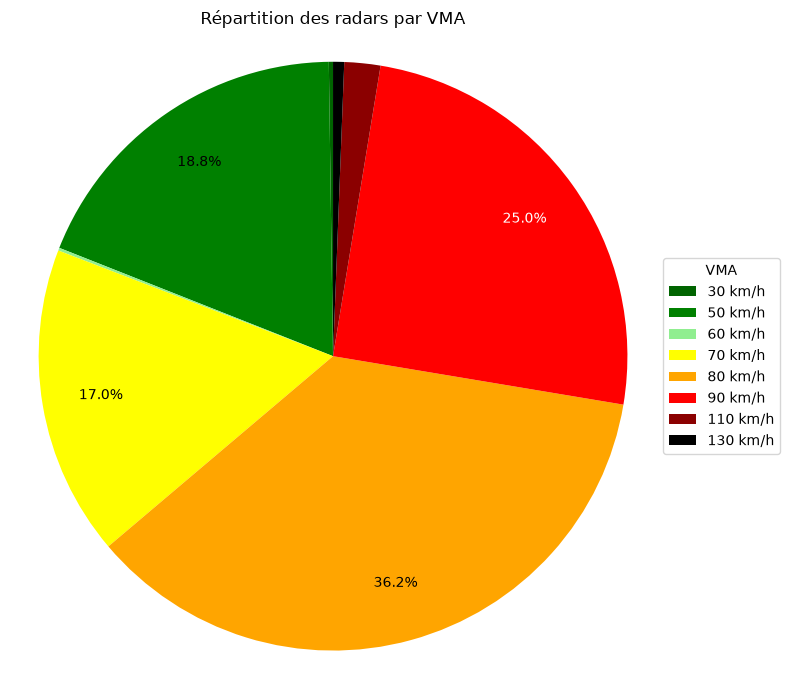

In [19]:
# Visualisation du nombre de radars par VMA en France

import matplotlib.pyplot as plt

vma_counts = dataframe["VMA"].value_counts().sort_index()
labels = [f"{int(v)} km/h" for v in vma_counts.index]

couleurs = {
    30: "darkgreen", 50: "green", 60: "lightgreen",
    70: "yellow", 80: "orange", 90: "red",
    110: "darkred", 130: "black"
}
colors = [couleurs.get(v, "gray") for v in vma_counts.index]

fig, ax = plt.subplots(figsize=(8, 7))

def format_pct(pct):
    return f"{pct:.1f}%" if pct > 2 else ""

wedges, texts, autotexts = ax.pie(
    vma_counts.values,
    autopct=format_pct,
    colors=colors,
    startangle=90,
    pctdistance=0.8
)

# Texte blanc lisible sur les tranches foncées (darkred, black, darkgreen)
for autotext, v in zip(autotexts, vma_counts.index):
    if couleurs.get(v) in ["darkred", "black", "darkgreen", "red"]:
        autotext.set_color("white")

ax.legend(
    wedges, labels,
    title="VMA",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Répartition des radars par VMA")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [23]:
# Carte des radars en France avec une VMA

import folium

# On garde uniquement les radars avec une VMA renseignée
radars_avec_vma = dataframe.dropna(subset=["VMA", "Latitude", "Longitude"])

# Centrage de la carte sur la France
carte = folium.Map(location=[46.6, 2.5], zoom_start=6)


couleurs = {
    30: "green", 50: "green", 60: "lightgreen",
    70: "yellow", 80: "orange", 90: "red",
    110: "darkred", 130: "black"
}

for _, radar in radars_avec_vma.iterrows():
    couleur = couleurs.get(radar["VMA"], "gray")
    folium.CircleMarker(
        location=[radar["Latitude"], radar["Longitude"]],
        radius=3,
        color=couleur,
        fill=True,
        fill_opacity=0.7,
        popup=f"{radar['Type de radar']} - VMA {radar['VMA']} km/h"
    ).add_to(carte)

carte

Date de mise en service
2003     17
2004     26
2005     88
2006     29
2007     57
2008    100
2009     92
2010     23
2011     77
2012    109
2013    119
2014     73
2015     27
2016    118
2017     45
2018      6
2019    211
2020    508
2021    280
2022    201
2023    234
2024    202
2025    102
Name: count, dtype: int64


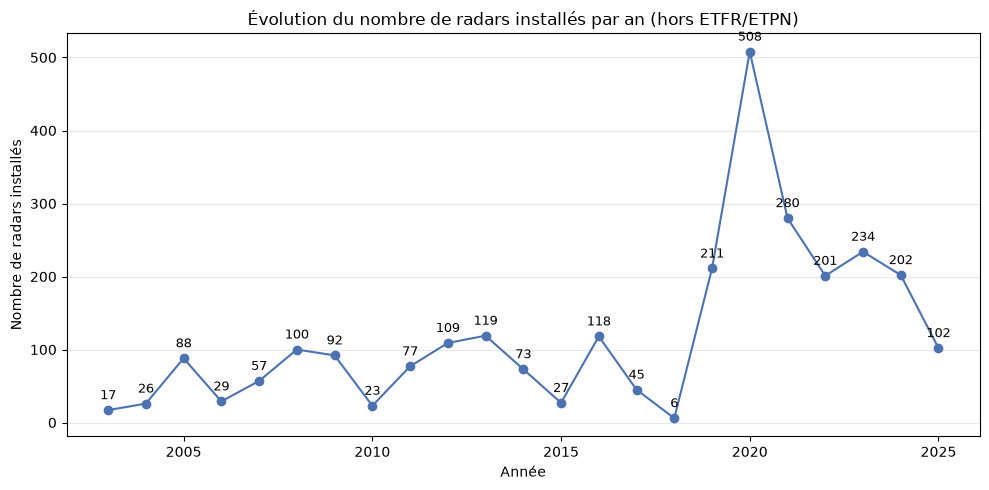

In [24]:
# Récupération du nombre de radars installés par an hors ETFR (feu rouge) et ETPN (passage à niveau)
# Car on s'intéresse qu'aux radars de vitesse
radars_avec_vma_prevue = dataframe[~dataframe["Type de radar"].isin(["ETFR", "ETPN"])]

radars_par_an = radars_avec_vma_prevue["Date de mise en service"].dt.year.value_counts().sort_index()
print(radars_par_an)


plt.figure(figsize=(10, 5))
plt.plot(radars_par_an.index, radars_par_an.values, marker="o", color="#4C72B0")

for x, y in zip(radars_par_an.index, radars_par_an.values):
    plt.text(x, y + 15, str(y), ha="center", fontsize=9)

plt.xlabel("Année")
plt.ylabel("Nombre de radars installés")
plt.title("Évolution du nombre de radars installés par an (hors ETFR/ETPN)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()